In [1]:
from wiki_dump_reader import Cleaner, iterate
from tqdm import tqdm
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from collections import Counter
import math
from tabulate import tabulate
import psutil
import os


In [2]:
languages = ["English","Bengali","Hindi"]
lang = [l.lower() for l in languages]

dump_files = [f"/mnt/Velocity_Vault/Wiki_Dump/Dump/{l}_dump.xml" for l in lang]
raw_corpus_files = [f"/mnt/Velocity_Vault/Wiki_Dump/Corpus/{l}_corpus.txt" for l in lang]
corpus_files = [f"/mnt/Velocity_Vault/Wiki_Dump/Corpus/{l}_processed.txt" for l in lang]


In [3]:

def write_corpus(dump,corpus):
    cleaner = Cleaner()
    
    # First, count the total number of pages for the progress bar
    total_pages = sum(1 for _ in iterate(dump))
    # print(f" {total_pages} pages to process.")
    
    with open(corpus, 'w', encoding='utf-8') as output:
        
        with tqdm(iterate(dump), total=total_pages, unit="page") as pbar:
            for title, text in pbar:
                
                text = cleaner.clean_text(text)                
                cleaned_text, _ = cleaner.build_links(text)
                output.write(title + '\n' + cleaned_text + '\n') # type: ignore
                    
            
    
    
    print(f"Corpus saved to: {corpus}")

# for l,dump_file,raw_corpus_file in zip(languages,dump_files,raw_corpus_files):
#     print("Constructing Corpus for ",l)
#     write_corpus(dump_file,raw_corpus_file)


In [4]:

def clean_hindi_line(line):
    cleaned = re.sub(r'[^\u0900-\u097F ]', ' ', line)
    cleaned = re.sub(r'[\u0966-\u096F]', ' ', cleaned)
    cleaned = re.sub(r'[।॥]', ' ', cleaned)
    cleaned = re.sub(r' +', ' ', cleaned)
    cleaned = cleaned.strip()
    return cleaned

def clean_odia_line(line):
    
    cleaned = re.sub(r'[^\u0B00-\u0B7F ]', ' ', line)
    
    # Replace multiple spaces with a single space
    cleaned = re.sub(r' +', ' ', cleaned)
    
    # Remove leading and trailing spaces
    cleaned = cleaned.strip()
    
    return cleaned

def clean_bengali_line(line):
    
    cleaned = re.sub(r'[^\u0980-\u09FF ]', ' ', line)
    
    # Replace multiple spaces with single space
    cleaned = re.sub(r' +', ' ', cleaned)
    
    # Remove leading and trailing spaces
    cleaned = cleaned.strip()
    
    return cleaned

def clean_english_line(line):
    # Convert all text to lowercase first
    line = line.lower()
    
    # Keep only lowercase English letters (a-z) and spaces
    cleaned = re.sub(r'[^a-z ]', ' ', line)
    
    # Replace multiple spaces with single space
    cleaned = re.sub(r' +', ' ', cleaned)
    
    # Remove leading and trailing spaces
    cleaned = cleaned.strip()
    
    return cleaned

language_cleaner = {"Hindi":clean_hindi_line,
                    "Odia":clean_odia_line,
                    "Bengali":clean_bengali_line,
                    "English":clean_english_line}

In [5]:

def preprocess_corpus(clean_line,source_file, dest_file):
    
    total_lines=0
    
    with open(source_file, 'r', encoding='utf-8') as src:
        total_lines=0
        for _ in src:
            total_lines+=1
            
    # print(f"Found {total_lines} lines to process.")
    
    try:
        with open(source_file, 'r', encoding='utf-8') as src:
            with open(dest_file, 'w', encoding='utf-8') as dest:
                
                first_line = True
                
                with tqdm(src, total=total_lines, unit="line") as pbar:
                    for line in pbar:
                        # Clean the current line
                        
                        cleaned_line = clean_line(line)

                        if not cleaned_line:
                            continue
                        
                        if not first_line:
                            dest.write(' ')
                        else:
                            first_line = False
                        
                        # Write the cleaned line (without newline)
                        dest.write(cleaned_line)
                    
    except Exception as e:
        print(f"An error occurred: {e}")
        
    print(f"Processed Corpus saved to: {dest_file}")
        

# for l,corpus_file,raw_corpus_file in zip(languages,corpus_files,raw_corpus_files):
#     print("Pre-processing Corpus for ",l)
#     preprocess_corpus(language_cleaner[l],raw_corpus_file,corpus_file)


In [6]:
def tokenize_corpus(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        words = text.split()
        print(f"Loaded {len(words):,} total words, {len(set(words)):,} unique words")
        return words
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return []
    except Exception as e:
        print(f"Error loading corpus: {e}")
        return []

In [7]:

def calculate_word_frequencies(words):
    word_counts = Counter(words)
    sorted_words = word_counts.most_common()
    frequencies = [count for _, count in sorted_words]
    ranks = list(range(1, len(frequencies) + 1))
    return frequencies, ranks, dict(sorted_words)



In [8]:

def word_analysis(corpus_file):
    words = tokenize_corpus(corpus_file)
    
    frequencies, ranks, word_freq_dict = calculate_word_frequencies(words)
    
    properties={}
    properties['frequencies']=frequencies
    properties['ranks']=ranks
    properties['word_freq_dict']=word_freq_dict
    
    return words,properties

word_tokens = []
word_properties = []

for i,l,corpus_file in zip([i for i in range(len(languages))],languages,corpus_files):
    
    print("Analyzing Words for ",l)
    
    word_stuff = word_analysis(corpus_file)
    
    word_tokens.append(word_stuff[0])
    word_properties.append(word_stuff[1])

Analyzing Words for  English
Loaded 113,146,814 total words, 1,057,440 unique words
Analyzing Words for  Bengali
Loaded 104,009,930 total words, 1,478,174 unique words
Analyzing Words for  Hindi
Loaded 88,757,626 total words, 868,332 unique words


Zipf Law and Mandelbrot Law Analysis

In [9]:

def zipf_law(rank, alpha, C):
    return C / (rank ** alpha)

def mandelbrot_law(rank, alpha, beta, C):
    return C / ((rank + beta) ** alpha)


In [10]:
def zipf_mandelbrot_models(ranks, frequencies):
    ranks_np = np.array(ranks)
    freqs_np = np.array(frequencies)
    results = {}
    
    try:
        def zipf_wrapper(rank, alpha, C):
            return zipf_law(rank, alpha, C)
        
        initial_guess = [1.0,frequencies[0]]
        params, _ = curve_fit(zipf_wrapper, ranks_np, freqs_np, p0=initial_guess, maxfev=5000)
        alpha_zipf, c_zipf = params
        
        zipf_pred = zipf_law(ranks_np, alpha_zipf, c_zipf)
        zipf_r2 = r2_score(freqs_np, zipf_pred)
        zipf_rmse = np.sqrt(mean_squared_error(freqs_np, zipf_pred))
        
        results['zipf'] = {
            'alpha': alpha_zipf,
            'C': c_zipf,
            'r2': zipf_r2,
            'rmse': zipf_rmse,
            'predictions': zipf_pred
        }
        
    except Exception as e:
        print(f"Error fitting Zipf's law: {e}")
        results['zipf'] = None
    
    try:
        def mandelbrot_wrapper(rank, alpha, beta, C):
            return mandelbrot_law(rank, alpha, beta, C)
        
        initial_guess = [1.0, 2.0, frequencies[0]]
        params, _ = curve_fit(mandelbrot_wrapper, ranks_np, freqs_np, 
                             p0=initial_guess, maxfev=5000)
        alpha_mandel, beta_mandel , c_mandel= params
        
        mandel_pred = mandelbrot_law(ranks_np, alpha_mandel, beta_mandel, c_mandel)
        mandel_r2 = r2_score(freqs_np, mandel_pred)
        mandel_rmse = np.sqrt(mean_squared_error(freqs_np, mandel_pred))
        
        results['mandelbrot'] = {
            'alpha': alpha_mandel,
            'beta': beta_mandel,
            'C': c_mandel,
            'r2': mandel_r2,
            'rmse': mandel_rmse,
            'predictions': mandel_pred
        }
    except Exception as e:
        print(f"Error fitting Mandelbrot's law: {e}")
        results['mandelbrot'] = None
    
    return results

In [11]:

def analyze_top_words(word_freq_dict, top_percent=5):
    total_words = len(word_freq_dict)
    num_top_words = math.ceil(total_words * top_percent / 100)
    top_words = sorted(word_freq_dict.items(), key=lambda x: x[1], reverse=True)[:num_top_words]
    
    df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])
    df['Rank'] = range(1, len(df) + 1)
    df['Percentage'] = (df['Frequency'] / df['Frequency'].sum()) * 100
    df['Cumulative_Percentage'] = df['Percentage'].cumsum()
    
    return df


In [12]:
def plot_law_analysis(ranks, frequencies, model_results):
    plt.figure(figsize=(12, 8))
    
    ranks_np = np.array(ranks)
    freqs_np = np.array(frequencies)
    
    plt.loglog(ranks_np, freqs_np, 'o', markersize=3, alpha=0.6, label='Actual Data')
    
    if model_results['zipf']:
        zipf_pred = model_results['zipf']['predictions']
        plt.loglog(ranks_np, zipf_pred, 'r--', linewidth=2, 
                  label=f'Zipf (α={model_results["zipf"]["alpha"]:.3f}, R²={model_results["zipf"]["r2"]:.3f})')
    
    if model_results['mandelbrot']:
        mandel_pred = model_results['mandelbrot']['predictions']
        plt.loglog(ranks_np, mandel_pred, 'g--', linewidth=2, 
                  label=f'Mandelbrot (α={model_results["mandelbrot"]["alpha"]:.3f}, β={model_results["mandelbrot"]["beta"]:.3f}, R²={model_results["mandelbrot"]["r2"]:.3f})')
    
    plt.xlabel('Rank (log scale)')
    plt.ylabel('Frequency (log scale)')
    plt.title('Zipf\'s Law and Mandelbrot Model Comparison\nRank-Frequency Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [13]:

def identify_deviation_points(ranks, frequencies, model_results):
    ranks_np = np.array(ranks)
    freqs_np = np.array(frequencies)
    deviations = {}
    
    if model_results['zipf']:
        zipf_rel_error = np.abs((freqs_np - model_results['zipf']['predictions']) / freqs_np)
        max_zipf_dev = np.argmax(zipf_rel_error)
        deviations['zipf'] = {
            'max_deviation_rank': ranks_np[max_zipf_dev],
            'max_deviation_error': zipf_rel_error[max_zipf_dev]
        }
    
    if model_results['mandelbrot']:
        mandel_rel_error = np.abs((freqs_np - model_results['mandelbrot']['predictions']) / freqs_np)
        max_mandel_dev = np.argmax(mandel_rel_error)
        deviations['mandelbrot'] = {
            'max_deviation_rank': ranks_np[max_mandel_dev],
            'max_deviation_error': mandel_rel_error[max_mandel_dev]
        }
    
    return deviations


In [14]:
def print_zipf_prdiction(model_results):
    
    print("\nMODEL PARAMETERS AND FIT QUALITY")
    print("=" * 50)
    
    comparison_data = []
    if model_results['zipf']:
        comparison_data.append([
            "Zipf's Law", 
            model_results['zipf']['alpha'], 
            "N/A", 
            model_results['zipf']['r2'], 
            model_results['zipf']['rmse']
        ])
    
    if model_results['mandelbrot']:
        comparison_data.append([
            "Mandelbrot's Law", 
            model_results['mandelbrot']['alpha'], 
            model_results['mandelbrot']['beta'], 
            model_results['mandelbrot']['r2'], 
            model_results['mandelbrot']['rmse']
        ])
    
    comparison_df = pd.DataFrame(comparison_data, 
                                columns=['Model', 'Alpha (α)', 'Beta (β)', 'R²', 'RMSE'])
    print(comparison_df.to_string(index=False))
    
    if model_results['zipf'] and model_results['mandelbrot']:
        if model_results['mandelbrot']['r2'] > model_results['zipf']['r2']:
            print("\n Mandelbrot's law provides a better fit (higher R²)")
        else:
            print("\n Zipf's law provides a better fit (higher R²)")

In [15]:

def print_frequent_words(top_words_df, m=7,max_display=70):
    print(f"\nMOST FREQUENT WORDS ANALYSIS")
    print("=" * 50)
    print(f"These {len(top_words_df)} words account for {top_words_df['Cumulative_Percentage'].iloc[-1]:.1f}% of all word occurrences")
    
    words = top_words_df['Word'].tolist()[:max_display]
    n_rows = math.ceil(len(words) / m)
    
    # reshape words into n x m grid
    grid = [words[i*m:(i+1)*m] for i in range(n_rows)]
    
    print(f"\nFrequent words:\n")
    print(tabulate(grid, tablefmt="grid"))


In [16]:
def print_zipf_deviation(deviations):
    print(f"\nMODEL DEVIATION ANALYSIS")
    print("=" * 50)
    if 'zipf' in deviations:
        print(f"Zipf's law has maximum deviation at rank {deviations['zipf']['max_deviation_rank']}")
        print(f"  Relative error: {deviations['zipf']['max_deviation_error']:.3f}")
    
    if 'mandelbrot' in deviations:
        print(f"Mandelbrot's law has maximum deviation at rank {deviations['mandelbrot']['max_deviation_rank']}")
        print(f"  Relative error: {deviations['mandelbrot']['max_deviation_error']:.3f}")

Zipf's Law for  English


/tmp/ipykernel_239354/413615172.py:5: RuntimeWarning: invalid value encountered in power
  return C / ((rank + beta) ** alpha)


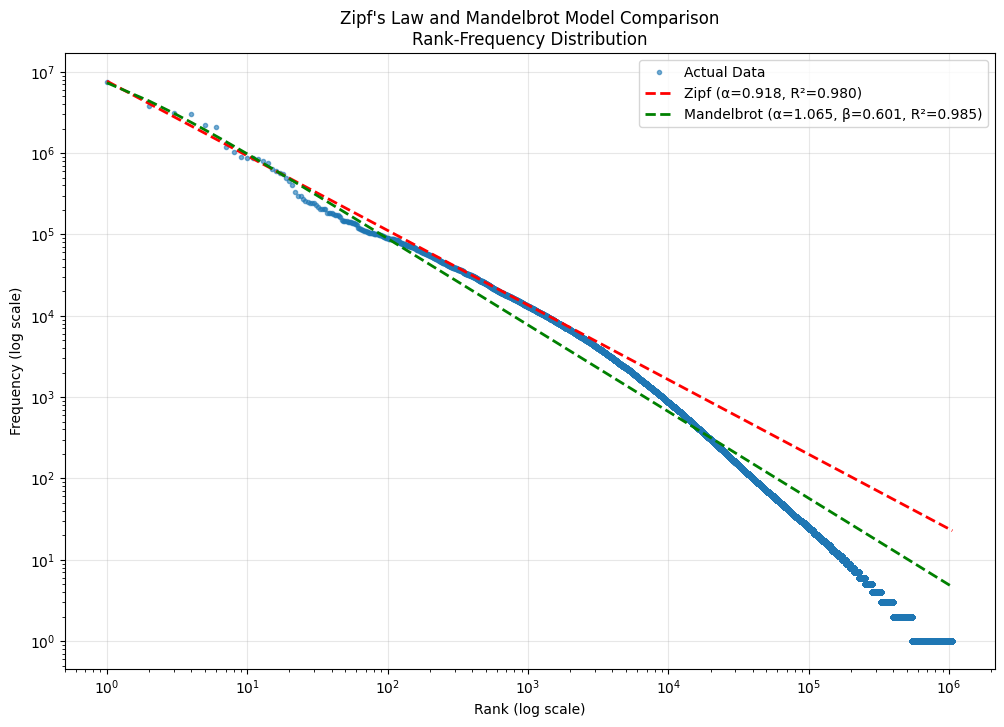


MODEL PARAMETERS AND FIT QUALITY
           Model  Alpha (α)  Beta (β)       R²        RMSE
      Zipf's Law   0.917530       N/A 0.980384 1429.179729
Mandelbrot's Law   1.065013  0.601082 0.985484 1229.399080

 Mandelbrot's law provides a better fit (higher R²)

MODEL DEVIATION ANALYSIS
Zipf's law has maximum deviation at rank 548721
  Relative error: 40.604
Mandelbrot's law has maximum deviation at rank 548721
  Relative error: 8.338
Zipf's Law for  Bengali


/tmp/ipykernel_239354/413615172.py:5: RuntimeWarning: invalid value encountered in power
  return C / ((rank + beta) ** alpha)


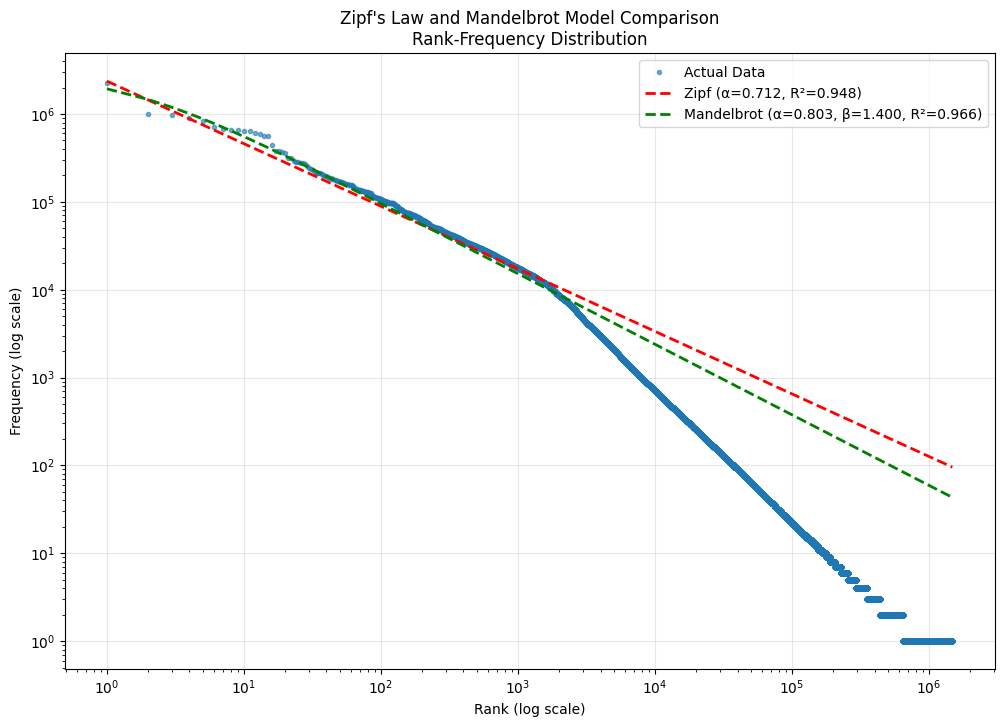


MODEL PARAMETERS AND FIT QUALITY
           Model  Alpha (α)  Beta (β)       R²       RMSE
      Zipf's Law   0.712155       N/A 0.947999 783.953851
Mandelbrot's Law   0.803298  1.399639 0.965789 635.868359

 Mandelbrot's law provides a better fit (higher R²)

MODEL DEVIATION ANALYSIS
Zipf's law has maximum deviation at rank 642343
  Relative error: 172.020
Mandelbrot's law has maximum deviation at rank 642343
  Relative error: 83.457
Zipf's Law for  Hindi


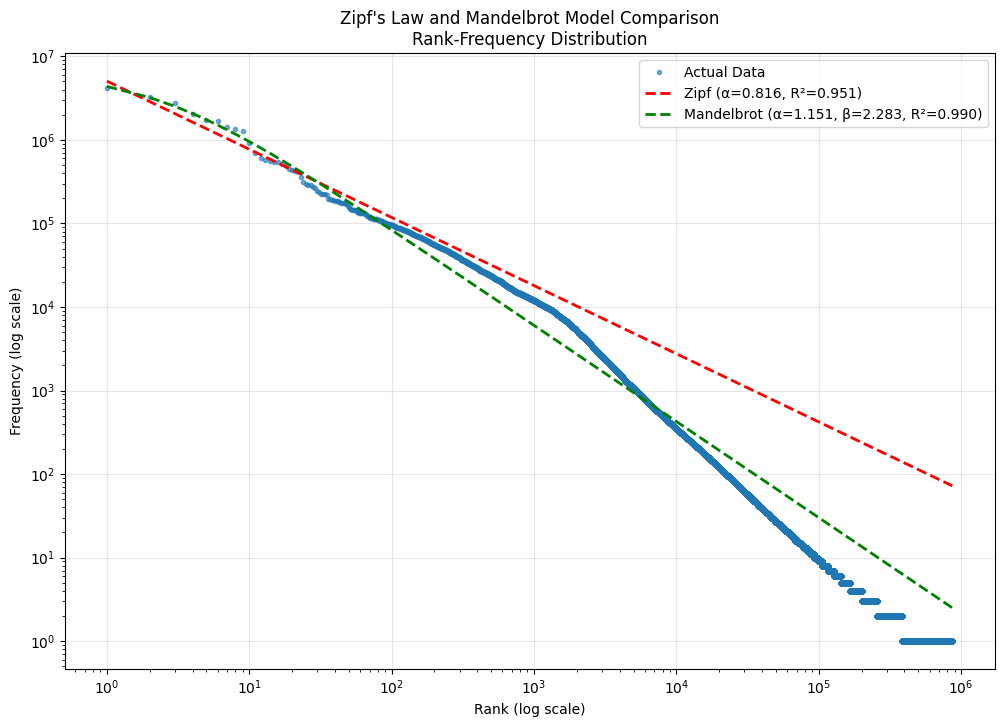


MODEL PARAMETERS AND FIT QUALITY
           Model  Alpha (α)  Beta (β)       R²        RMSE
      Zipf's Law   0.815882       N/A 0.950636 1833.923488
Mandelbrot's Law   1.151098  2.283379 0.990279  813.804015

 Mandelbrot's law provides a better fit (higher R²)

MODEL DEVIATION ANALYSIS
Zipf's law has maximum deviation at rank 385050
  Relative error: 139.072
Mandelbrot's law has maximum deviation at rank 385050
  Relative error: 5.377


In [17]:

def zipf_mandelbrot_law_analysis(words,properties):
    if not words:
        return
    
    print("=" * 50)
    
    frequencies, ranks = properties['frequencies'], properties['ranks']
    model_results = zipf_mandelbrot_models(ranks, frequencies)
    deviations = identify_deviation_points(ranks, frequencies, model_results)
    
    plot_law_analysis(ranks, frequencies, model_results)
    
    print_zipf_prdiction(model_results)
    
    print_zipf_deviation(deviations)
    
for l,word_t, word_p in zip(languages,word_tokens,word_properties):
    print("Zipf's Law for ",l)
    zipf_mandelbrot_law_analysis(word_t,word_p)

In [18]:

def freuquent_word_analysis(properties):
    
    word_freq_dict = properties['word_freq_dict']
    
    top_words_df = analyze_top_words(word_freq_dict, 5)
    print_frequent_words(top_words_df)
    
for l,word_p in zip(languages,word_properties):
    
    print("Frequent Words in ",l)
    freuquent_word_analysis(word_p)

Frequent Words in  English

MOST FREQUENT WORDS ANALYSIS
These 52872 words account for 100.0% of all word occurrences

Frequent words:

+----------+--------+----------+------------+-------+------------+----------+
| the      | of     | in       | and        | a     | to         | was      |
+----------+--------+----------+------------+-------+------------+----------+
| s        | for    | as       | on         | is    | by         | with     |
+----------+--------+----------+------------+-------+------------+----------+
| from     | he     | at       | that       | his   | it         | an       |
+----------+--------+----------+------------+-------+------------+----------+
| were     | also   | which    | are        | new   | this       | be       |
+----------+--------+----------+------------+-------+------------+----------+
| first    | or     | had      | one        | after | its        | has      |
+----------+--------+----------+------------+-------+------------+----------+
| thei

Heap Analysis

In [19]:

def compute_vocabulary_growth(words, sample_points):
    
    total_tokens = len(words)
    step_size = max(1, total_tokens // sample_points)
    
    corpus_sizes = []
    vocabulary_sizes = []
    vocabulary = set()
    
    print(f"Computing vocabulary growth for {total_tokens:,} tokens...")
    
    for i in tqdm(range(len(words))):
        word = words[i]
        vocabulary.add(word)
        
        if i % step_size == 0 or i == total_tokens - 1:
            corpus_sizes.append(i + 1)
            vocabulary_sizes.append(len(vocabulary))
    
    return np.array(corpus_sizes), np.array(vocabulary_sizes)


In [20]:
growth_data=[]

for l,word_t in zip(languages,word_tokens):
    print("Vocabularity Growth rate for ",l)
    growth_data.append(compute_vocabulary_growth(word_t, 0.01*len(word_t)))

Vocabularity Growth rate for  English
Computing vocabulary growth for 113,146,814 tokens...


100%|██████████| 113146814/113146814 [00:31<00:00, 3539797.61it/s]


Vocabularity Growth rate for  Bengali
Computing vocabulary growth for 104,009,930 tokens...


100%|██████████| 104009930/104009930 [00:39<00:00, 2627309.85it/s]


Vocabularity Growth rate for  Hindi
Computing vocabulary growth for 88,757,626 tokens...


100%|██████████| 88757626/88757626 [00:29<00:00, 3012154.76it/s]


In [21]:


def heaps_law(N, K, beta):
    return K * (N ** beta)

def heaps_law_model(corpus_sizes, vocabulary_sizes):
    
    try:
        # Use nonlinear least squares to fit Heaps' law
        def heaps_wrapper(N, K, beta):
            return heaps_law(N, K, beta)
        
        # Initial guesses: K around 10-100, beta around 0.5-0.7 (typical values)
        initial_guess = [50.0, 0.5]
        
        # Fit the model
        params, _ = curve_fit(heaps_wrapper, corpus_sizes, vocabulary_sizes, 
                             p0=initial_guess, maxfev=5000)
        
        K, beta = params
        
        # Calculate predictions and metrics
        predictions = heaps_law(corpus_sizes, K, beta)
        
        
        r2 = r2_score(vocabulary_sizes, predictions)
        mse = mean_squared_error(vocabulary_sizes, predictions)
        rmse = np.sqrt(mse)
        
        return {
            'K': K,
            'beta': beta,
            'r2': r2,
            'mse': mse,
            'rmse': rmse,
            'predictions': predictions
        }
        
    except Exception as e:
        print(f"Error fitting Heaps' law: {e}")
        return None


In [22]:

def plot_heaps_law(corpus_sizes, vocabulary_sizes, heaps_results):
    
    plt.figure(figsize=(7, 7))
    
    # Plot actual data
    plt.plot(corpus_sizes, vocabulary_sizes, 'o', markersize=4, alpha=0.7, 
              label='Actual Vocabulary Growth')
    
    # Plot fitted Heaps' law
    if heaps_results:
        plt.plot(corpus_sizes, heaps_results['predictions'], 'r-', linewidth=2,
                  label=f"Heaps' Law Fit (K={heaps_results['K']:.2f}, β={heaps_results['beta']:.3f}")
    
    plt.xlabel('Corpus Size')
    plt.ylabel('Vocabulary Size')
    plt.title(f'Heaps\' Law - Vocabulary Growth for Corpus')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Heap's Law for  English

HEAPS' LAW ANALYSIS


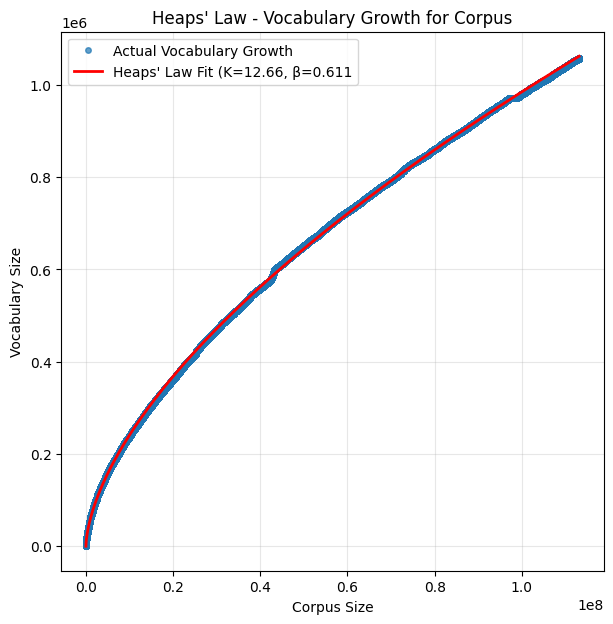


HEAPS' LAW PARAMETERS
K parameter: 12.6594
β parameter: 0.6114
R² score: 0.9998
MSE: 16252321.4747
RMSE: 4031.4168
Heap's Law for  Bengali

HEAPS' LAW ANALYSIS


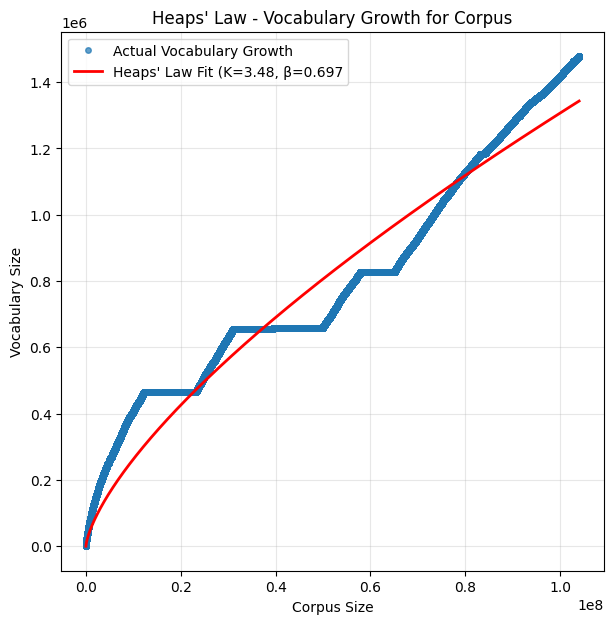


HEAPS' LAW PARAMETERS
K parameter: 3.4808
β parameter: 0.6968
R² score: 0.9383
MSE: 7446984685.0704
RMSE: 86295.9135
Heap's Law for  Hindi

HEAPS' LAW ANALYSIS


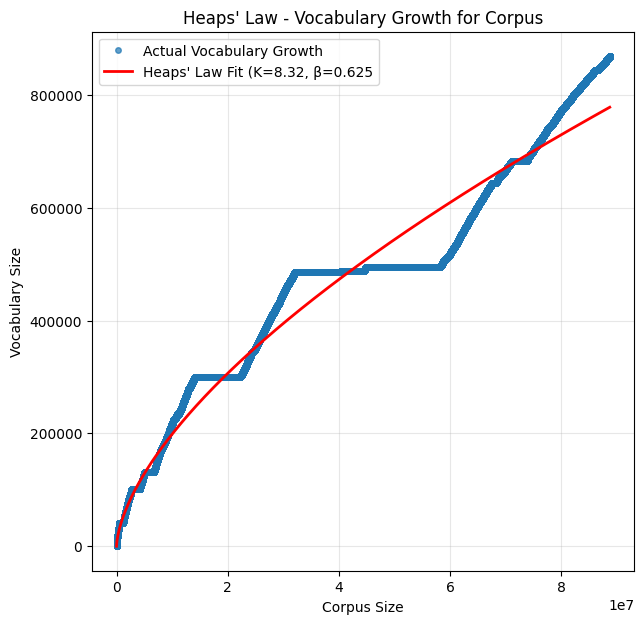


HEAPS' LAW PARAMETERS
K parameter: 8.3246
β parameter: 0.6254
R² score: 0.9492
MSE: 2076292241.7697
RMSE: 45566.3499


In [23]:

def analyze_heaps_law(words, growth):
    
    if not words:
        return None
    
    print("\n" + "="*60)
    print("HEAPS' LAW ANALYSIS")
    print("="*60)
    
    # Compute vocabulary growth
    corpus_sizes, vocabulary_sizes = growth
    
    # Fit Heaps' law
    heaps_results = heaps_law_model(corpus_sizes, vocabulary_sizes)
    
    if heaps_results:
        # Plot results
        plot_heaps_law(corpus_sizes, vocabulary_sizes, heaps_results)
        
        # Print results
        print("\nHEAPS' LAW PARAMETERS")
        print("=" * 30)
        print(f"K parameter: {heaps_results['K']:.4f}")
        print(f"β parameter: {heaps_results['beta']:.4f}")
        print(f"R² score: {heaps_results['r2']:.4f}")
        print(f"MSE: {heaps_results['mse']:.4f}")
        print(f"RMSE: {heaps_results['rmse']:.4f}")
    
    return heaps_results


heaps_results=[]

for l,word_t,growth_d in zip(languages,word_tokens,growth_data):
    
    print("Heap's Law for ",l)
    heaps_results.append(analyze_heaps_law(word_t, growth_d))

Scaling Memory

In [24]:
def corpus_stats(file_path):
    
    vocab = set()
    num_docs = 0

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            words = line.strip().split()
            if not words:
                continue
            num_docs += 1
            vocab.update(words)

    vocab_size = len(vocab)
    return vocab_size, num_docs


def memory_requirement(vocab_size, num_docs):
    
    bytes_needed = vocab_size * num_docs * 8
    mb = bytes_needed / (1024**2)
    gb = bytes_needed / (1024**3)
    tb = bytes_needed / (1024**4)
    return mb, gb, tb


In [25]:

def summarize_corpora(file_paths):
    
    table = []
    headers = ["Corpus", "Vocabulary", "Documents", "Memory (MB)", "Memory (GB)", "Memory (TB)", "Fits in Machine?"]

    # Get available RAM in bytes
    available_ram = psutil.virtual_memory().available
    available_gb = available_ram / (1024**3)

    for file in file_paths:
        V, D = corpus_stats(file)
        mb, gb, tb = memory_requirement(V, D)

        fits = "Yes" if (gb <= available_gb) else "No"

        table.append([os.path.basename(file),f"{V:,}",f"{D:,}",f"{mb:,.2f}",f"{gb:,.2f}",f"{tb:,.3f}",fits])

    print(tabulate(table, headers=headers, tablefmt="github"))
    print(f"\nAvailable system RAM: {available_gb:.2f} GB")



summarize_corpora(corpus_files)

| Corpus                | Vocabulary   |   Documents |   Memory (MB) |   Memory (GB) |   Memory (TB) | Fits in Machine?   |
|-----------------------|--------------|-------------|---------------|---------------|---------------|--------------------|
| english_processed.txt | 1,057,440    |           1 |          8.07 |          0.01 |             0 | Yes                |
| bengali_processed.txt | 1,478,174    |           1 |         11.28 |          0.01 |             0 | Yes                |
| hindi_processed.txt   | 868,332      |           1 |          6.62 |          0.01 |             0 | Yes                |

Available system RAM: 0.65 GB


Regression on Heap's Law

In [26]:

def heaps_law_regression(corpus_sizes, vocabulary_sizes):
    """Fit Heaps' law using linear regression on log-transformed data"""
    # Remove any zero or negative values (shouldn't exist but safe)
    valid_indices = (corpus_sizes > 0) & (vocabulary_sizes > 0)
    corpus_sizes = corpus_sizes[valid_indices]
    vocabulary_sizes = vocabulary_sizes[valid_indices]
    
    # Log-transform the data with safety checks
    log_N = np.log(corpus_sizes)
    log_V = np.log(vocabulary_sizes)
    
    # Remove infinite values (just in case)
    finite_mask = np.isfinite(log_N) & np.isfinite(log_V)
    log_N = log_N[finite_mask]
    log_V = log_V[finite_mask]

    
    model = LinearRegression()
    model.fit(log_N.reshape(-1, 1), log_V)
    
    # Extract parameters
    beta = model.coef_[0]
    log_K = model.intercept_
    K = np.exp(log_K)
    
    # Calculate predictions
    log_pred = model.predict(log_N.reshape(-1, 1))
    predictions = np.exp(log_pred)

    # Calculate additional metrics
    r2 = r2_score(log_V, log_pred)
    mse = mean_squared_error(vocabulary_sizes, predictions)
    rmse = np.sqrt(mse)
    
    return {
        'K': K,
        'beta': beta,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'predictions': predictions
    }

In [27]:

def plot_heaps_law_regression(corpus_sizes, vocabulary_sizes, results):
    """Create plots for Heaps' law fit"""
    fig, (ax2) = plt.subplots(1, figsize=(7, 7))
    
    ax2.plot(corpus_sizes, vocabulary_sizes, 'o', markersize=3, alpha=0.7, label='Actual Data')
    ax2.plot(corpus_sizes, results['predictions'], 'r-', linewidth=2, label='Heaps\' Law Fit')
    
    ax2.set_xlabel('Corpus Size (log scale)')
    ax2.set_ylabel('Vocabulary Size (log scale)')
    ax2.set_title(f'Heaps\' Law - Log-Log Scale\nR² = {results["r2"]:.4f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [28]:

def analyze_regression(words,growth):
    
    if not words:
        return None
    
    print("=" * 50)
    
    # Compute vocabulary growth
    corpus_sizes, vocabulary_sizes = growth
    print(f"Corpus size: {len(words):,} tokens")
    print(f"Final vocabulary: {vocabulary_sizes[-1]:,} words")
    
    # Fit using linear regression on log-transformed data
    results = heaps_law_regression(corpus_sizes, vocabulary_sizes)
    
    # Display results
    print(f"\nHEAPS' LAW FITTING RESULTS (Linear Regression on Log-Transformed Data):")
    print("=" * 70)
    print(f"K parameter: {results['K']:.4f}")
    print(f"β parameter: {results['beta']:.4f}")
    print(f"R² score: {results['r2']:.4f}")
    print(f"MSE: {results['mse']:.4f}")
    print(f"RMSE: {results['rmse']:.4f}")
    
    # Plot results
    plot_heaps_law_regression(corpus_sizes, vocabulary_sizes, results)
    
    return results


Heap's Law via Regression for  English
Corpus size: 113,146,814 tokens
Final vocabulary: 1,057,440 words

HEAPS' LAW FITTING RESULTS (Linear Regression on Log-Transformed Data):
K parameter: 12.6029
β parameter: 0.6116
R² score: 0.9997
MSE: 16341426.8423
RMSE: 4042.4531


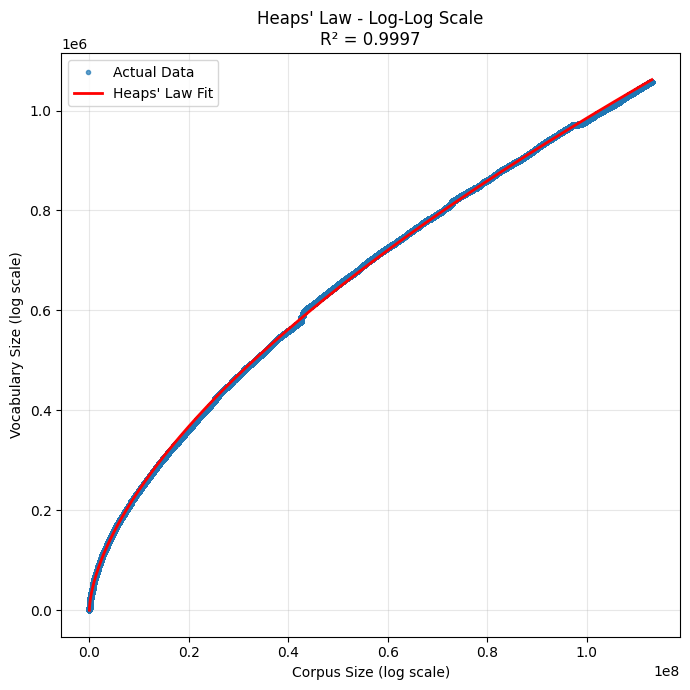

Heap's Law via Regression for  Bengali
Corpus size: 104,009,930 tokens
Final vocabulary: 1,478,174 words

HEAPS' LAW FITTING RESULTS (Linear Regression on Log-Transformed Data):
K parameter: 46.2889
β parameter: 0.5518
R² score: 0.9554
MSE: 10478641736.7316
RMSE: 102365.2370


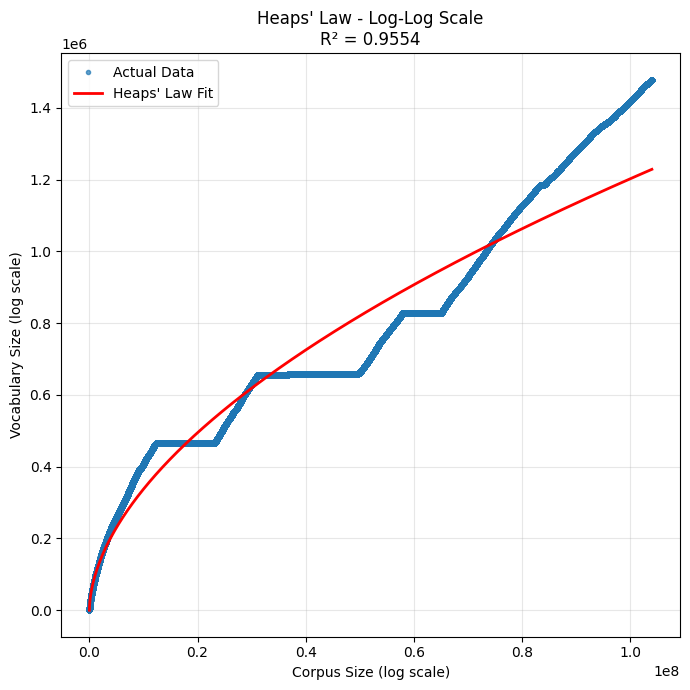

Heap's Law via Regression for  Hindi
Corpus size: 88,757,626 tokens
Final vocabulary: 868,332 words

HEAPS' LAW FITTING RESULTS (Linear Regression on Log-Transformed Data):
K parameter: 11.0420
β parameter: 0.6093
R² score: 0.9771
MSE: 2093150224.2699
RMSE: 45750.9587


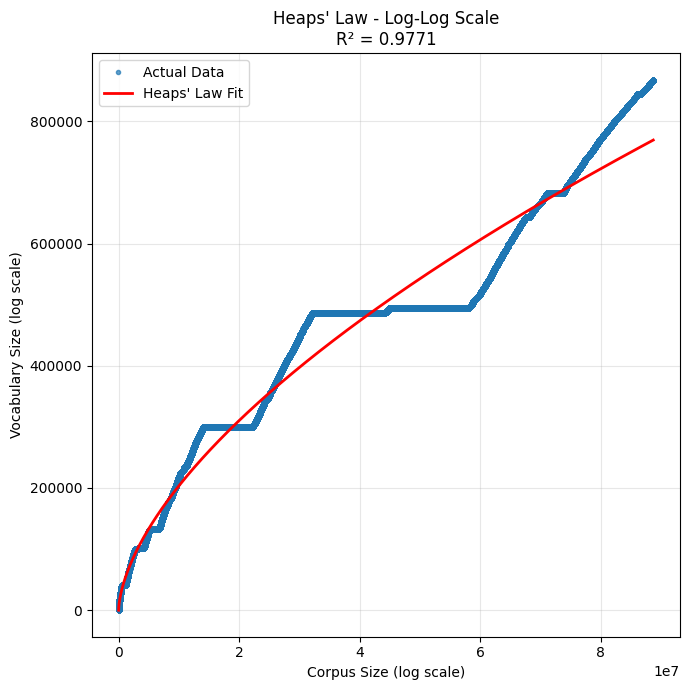

In [29]:
regression_results=[]

for l,word_t,growth_d in zip(languages,word_tokens,growth_data):
    
    print("Heap's Law via Regression for ",l)
    regression_results.append(analyze_regression(word_t, growth_d))


Comparison

In [30]:
def compare_fitting_methods(regression_results, curve_fit_results):
    
    # Create comparison data
    comparison_data = [
        {
            'Method': 'Linear Regression (Log-Transformed)',
            'K': regression_results['K'],
            'β': regression_results['beta'],
            'R²': regression_results['r2'],
            'MSE': regression_results['mse'],
            'RMSE': regression_results['rmse']
        },
        {
            'Method': 'Direct Curve Fitting',
            'K': curve_fit_results['K'],
            'β': curve_fit_results['beta'],
            'R²': curve_fit_results['r2'],
            'MSE': curve_fit_results['mse'],
            'RMSE': curve_fit_results['rmse']
        }
    ]
    
    # Create DataFrame
    df = pd.DataFrame(comparison_data)
    
    # Calculate differences
    k_diff = abs(df.loc[0, 'K'] - df.loc[1, 'K']) / df.loc[0, 'K'] * 100 # type: ignore
    beta_diff = abs(df.loc[0, 'β'] - df.loc[1, 'β']) / df.loc[0, 'β'] * 100 # type: ignore
    r2_diff = df.loc[0, 'R²'] - df.loc[1, 'R²'] # type: ignore
    
    # Print detailed comparison
    print("COMPARISON OF FITTING METHODS")
    print("=" * 100)
    print(df.to_string(index=False, float_format=lambda x: f'{x:.6f}' if isinstance(x, float) else str(x)))
    print("\n" + "=" * 100)
    print("PARAMETER DIFFERENCES:")
    print(f"K parameter difference: {k_diff:.2f}%")
    print(f"β parameter difference: {beta_diff:.2f}%")
    print(f"R² difference: {r2_diff:.6f}")
    
    # Determine which method fits better
    if regression_results['r2'] > curve_fit_results['r2']:
        better_method = "Linear Regression (Log-Transformed)"
        improvement = regression_results['r2'] - curve_fit_results['r2']
        print(f"\nBetter fit: {better_method} (R² improvement: {improvement:.6f})")
    elif curve_fit_results['r2'] > regression_results['r2']:
        better_method = "Direct Curve Fitting"
        improvement = curve_fit_results['r2'] - regression_results['r2']
        print(f"\nBetter fit: {better_method} (R² improvement: {improvement:.6f})")
    else:
        print(f"\nBoth methods provide identical fit quality")
    
    return df


# Compare the methods

comparison_df=[]
for l,reg,heap in zip(languages,regression_results,heaps_results):
    print("\n\nComparing Models for ",l)
    comparison_df.append(compare_fitting_methods(reg, heap))



Comparing Models for  English
COMPARISON OF FITTING METHODS
                             Method         K        β       R²             MSE        RMSE
Linear Regression (Log-Transformed) 12.602865 0.611593 0.999739 16341426.842344 4042.453072
               Direct Curve Fitting 12.659411 0.611368 0.999778 16252321.474679 4031.416807

PARAMETER DIFFERENCES:
K parameter difference: 0.45%
β parameter difference: 0.04%
R² difference: -0.000039

Better fit: Direct Curve Fitting (R² improvement: 0.000039)


Comparing Models for  Bengali
COMPARISON OF FITTING METHODS
                             Method         K        β       R²                MSE          RMSE
Linear Regression (Log-Transformed) 46.288881 0.551802 0.955426 10478641736.731604 102365.236954
               Direct Curve Fitting  3.480764 0.696814 0.938326  7446984685.070401  86295.913490

PARAMETER DIFFERENCES:
K parameter difference: 92.48%
β parameter difference: 26.28%
R² difference: 0.017101

Better fit: Linear Regressio